In [209]:
#데이터 분석
import numpy as np
import pandas as pd

#데이터 시각화
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#머신러닝 로지스틱회귀
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [210]:
#한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

#경고문 패치
import warnings

warnings.filterwarnings('ignore')

In [211]:
import seaborn as sns 

df = sns.load_dataset("penguins") 
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


종, 성별 범주형

몸무게 연속형

In [212]:
df['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

 펭귄의 종, 성별, 몸무게를 예측

In [213]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [214]:
df.dropna(subset=['sex'], inplace=True)

In [215]:
df.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [216]:
# 종과 성별 / 몸무게 따로 예측
df['species_target'] = df['species'].map({
    'Adelie' : 0,
    'Gentoo' : 1,
    'Chinstrap' : 2
})
print(df['species_target'])

df['sex_target'] = df['sex'].map({
    'Male' : 0,
    'Female' : 1
})

df['island_encoded'] = df['island'].map({
    'Biscoe' : 0,
    'Dream' : 1,
    'Torgersen' : 2
})
y = df['species_target']
X = df.drop(['species','body_mass_g','sex','species_target','sex_target','island'], axis = 1)

0      0
1      0
2      0
4      0
5      0
      ..
338    1
340    1
341    1
342    1
343    1
Name: species_target, Length: 333, dtype: int64


In [217]:
X.columns

Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
       'island_encoded'],
      dtype='object')

In [218]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y 
)

In [219]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_target,sex_target,island_encoded
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,0,0,2
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0,1,2
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0,1,2
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0,1,2
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,0,0,2
...,...,...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,1,1,0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,1,1,0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,1,0,0
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,1,1,0


In [220]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [221]:
model = LogisticRegression(
    max_iter = 100,
    random_state = 42
)

In [222]:
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [223]:
y_pred=model.predict(X_test_scaled)

In [224]:
X_train_scaled

array([[ 0.53411254, -0.34240062, -0.88738114,  0.46584091],
       [ 0.29343477, -1.66606899,  0.64252968, -0.92644765],
       [ 0.99695439,  1.38855032,  0.1325594 ,  0.46584091],
       ...,
       [ 0.03424334,  1.28672967, -0.37741087,  0.46584091],
       [ 0.36748947, -0.03693869, -0.81452824,  0.46584091],
       [-1.92820611,  0.93035742, -0.81452824,  1.85812947]],
      shape=(266, 4))

In [225]:
accuracy = accuracy_score(y_test,y_pred)
print("logistic regression 정확도 : ",round(accuracy,4))

logistic regression 정확도 :  0.9701


In [226]:
print(classification_report(
    y_test,
    y_pred,
    target_names = df['species'].unique()
))

              precision    recall  f1-score   support

      Adelie       0.94      1.00      0.97        29
   Chinstrap       1.00      1.00      1.00        24
      Gentoo       1.00      0.86      0.92        14

    accuracy                           0.97        67
   macro avg       0.98      0.95      0.96        67
weighted avg       0.97      0.97      0.97        67



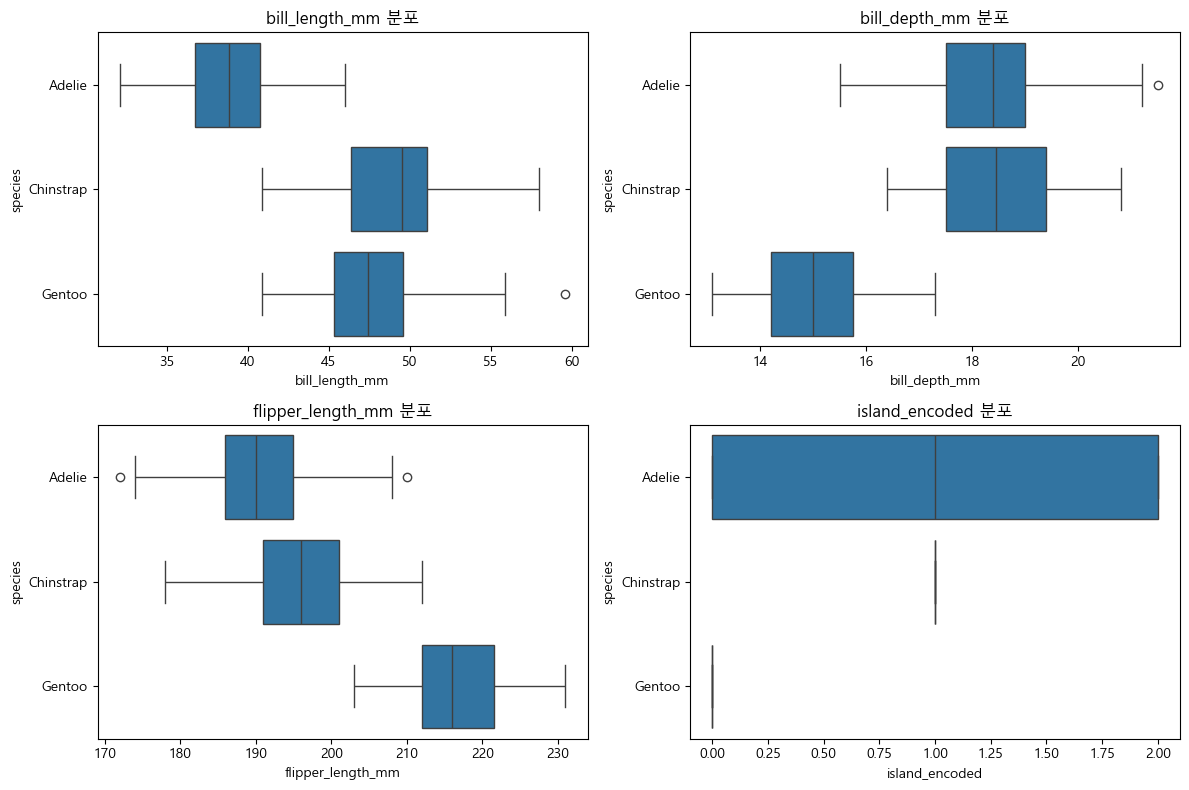

In [231]:
plt.figure(figsize=(12, 8))
#sns.boxplot(x=df['size'],y=df['tip'])
for i, col in enumerate(X.columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=col, y=df['species'])
    plt.title(f"{col} 분포")

plt.tight_layout()
plt.show()